In [1]:
import pandas as pd
import numpy as np
from autogluon.tabular import TabularDataset, TabularPredictor
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
odroid1 = pd.read_csv("https://raw.githubusercontent.com/brite3001/drawnapart/master/carbonyl/vec_21/odroid1_firefox_carbonyl21.csv")
odroid2 = pd.read_csv("https://raw.githubusercontent.com/brite3001/drawnapart/master/carbonyl/vec_21/odroid2_firefox_carbonyl21.csv")
odroid3 = pd.read_csv("https://raw.githubusercontent.com/brite3001/drawnapart/master/carbonyl/vec_21/odroid3_firefox_carbonyl21.csv")
odroid4 = pd.read_csv("https://raw.githubusercontent.com/brite3001/drawnapart/master/carbonyl/vec_21/odroid4_firefox_carbonyl21.csv")

In [3]:
rpi4a = pd.read_csv("https://raw.githubusercontent.com/brite3001/drawnapart/master/carbonyl/vec_21/rpi-4a_chrome_carbonyl21.csv")
rpi8a = pd.read_csv("https://raw.githubusercontent.com/brite3001/drawnapart/master/carbonyl/vec_21/rpi-8a_chrome_carbonyl21.csv")
rpi8b = pd.read_csv("https://raw.githubusercontent.com/brite3001/drawnapart/master/carbonyl/vec_21/rpi-8b_chrome_carbonyl21.csv")
rpi8c = pd.read_csv("https://raw.githubusercontent.com/brite3001/drawnapart/master/carbonyl/vec_21/rpi-8c_chrome_carbonyl21.csv")
rpi8d = pd.read_csv("https://raw.githubusercontent.com/brite3001/drawnapart/master/carbonyl/vec_21/rpi-8d_chrome_carbonyl21.csv")

In [4]:
df = pd.concat([odroid1[:1000], odroid2[:1000], odroid3[:1000], odroid4[:1000], rpi4a[:1000], rpi8a[:1000], rpi8b[:1000], rpi8c[:1000], rpi8d[:1000]])
df = df.sample(frac=1, random_state=29).reset_index(drop=True)
np.random.seed(29)

In [5]:
df.head()

,label,Feature 0,Feature 1,Feature 2,Feature 3,Feature 4,Feature 5,Feature 6,Feature 7,Feature 8,...,Feature 11,Feature 12,Feature 13,Feature 14,Feature 15,Feature 16,Feature 17,Feature 18,Feature 19,Feature 20
0,odroid4,89.8,86.9,86.3,85.2,84.6,84.7,84.5,84.7,84.6,...,85.0,84.8,85.0,85.0,84.6,84.9,84.9,84.9,84.7,85.4
1,odroid3,88.1,87.2,84.5,82.9,82.8,82.9,83.5,82.9,82.6,...,83.4,82.7,82.7,83.3,82.8,83.8,83.1,83.1,82.8,82.8
2,odroid2,89.4,86.6,86.2,85.2,85.0,84.7,84.9,85.1,84.9,...,85.0,84.8,85.0,85.0,85.1,84.7,84.9,84.7,85.1,84.8
3,odroid2,89.6,86.3,86.1,85.1,84.8,84.8,85.1,85.0,85.0,...,84.8,84.7,84.5,84.7,84.9,84.8,84.7,85.3,84.7,84.6
4,odroid1,90.3,86.8,86.3,85.0,85.1,84.9,85.2,84.7,84.8,...,84.7,84.5,85.2,85.0,85.8,85.0,85.0,84.9,85.1,84.8


In [6]:
len(df)

9000

In [7]:
stats_df = pd.DataFrame(columns=['data_amount', 'precision', 'recall', 'f1'])
best_model = {}
best_features = {}

for i in range(1000, 9000, 1000):
    train_data = df.head(i)
    test_data = df.tail(1000)

    predictor = TabularPredictor(label='label').fit(train_data, num_gpus=1, presets='medium_quality')
    y_pred = predictor.predict(test_data)
    y_pred_proba = predictor.predict_proba(test_data)
    results = predictor.evaluate(test_data, detailed_report=True)['classification_report']['weighted avg']

    new_row = {'data_amount': i, 'precision': results['precision'], 'recall':results['recall'], 'f1':results['f1-score']}
    stats_df.loc[len(stats_df)] = new_row

    model_leaderboard = predictor.leaderboard(test_data)
    # Which models came in the top three on the leaderboard most often?
    if model_leaderboard.loc[0]['model'] not in best_model:
        best_model[model_leaderboard.loc[0]['model']] = 1
    else:
        best_model[model_leaderboard.loc[0]['model']] += 1

    if model_leaderboard.loc[1]['model'] not in best_model:
        best_model[model_leaderboard.loc[1]['model']] = 1
    else:
        best_model[model_leaderboard.loc[1]['model']] += 1

    if model_leaderboard.loc[2]['model'] not in best_model:
        best_model[model_leaderboard.loc[2]['model']] = 1
    else:
        best_model[model_leaderboard.loc[2]['model']] += 1


    feature_importance = predictor.feature_importance(test_data)
    # Which features has the highest importance most often?
    if feature_importance.index[0] not in best_features:
        best_features[feature_importance.index[0]] = 1
    else:
        best_features[feature_importance.index[0]] += 1

    if feature_importance.index[1] not in best_features:
        best_features[feature_importance.index[1]] = 1
    else:
        best_features[feature_importance.index[1]] += 1

    if feature_importance.index[2] not in best_features:
        best_features[feature_importance.index[2]] = 1
    else:
        best_features[feature_importance.index[2]] += 1

No path specified. Models will be saved in: "AutogluonModels\ag-20250203_030600"
Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.2
Python Version:     3.11.11
Operating System:   Windows
Platform Machine:   AMD64
Platform Version:   10.0.26100
CPU Count:          32
Memory Avail:       46.74 GB / 63.72 GB (73.4%)
Disk Space Avail:   1282.13 GB / 1906.98 GB (67.2%)
Presets specified: ['medium_quality']
Beginning AutoGluon training ...
AutoGluon will save models to "c:\Users\zac\Documents\github\IoT-GPU-ID\Experiment 1 - DrawnApart\AutogluonModels\ag-20250203_030600"
Train Data Rows:    1000
Train Data Columns: 21
Label Column:       label
AutoGluon infers your prediction problem is: 'multiclass' (because dtype of label-column == object).
	9 unique label values:  ['odroid4', 'odroid3', 'odroid2', 'odroid1', 'rpi-4a', 'rpi-8a', 'rpi-8c', 'rpi-8d', 'rpi-8b']
	If 'multiclass' is not the correct problem_type, please manually specify t

[1000]	valid_set's multi_error: 0.261667


	0.75	 = Validation score   (accuracy)
	12.27s	 = Training   runtime
	0.02s	 = Validation runtime
Fitting model: LightGBM ...
	Training LightGBM with GPU, note that this may negatively impact model quality compared to CPU training.
	0.73	 = Validation score   (accuracy)
	20.51s	 = Training   runtime
	0.01s	 = Validation runtime
Fitting model: RandomForestGini ...
	0.7217	 = Validation score   (accuracy)
	0.62s	 = Training   runtime
	0.05s	 = Validation runtime
Fitting model: RandomForestEntr ...
	0.7317	 = Validation score   (accuracy)
	0.61s	 = Training   runtime
	0.06s	 = Validation runtime
Fitting model: CatBoost ...
	Training CatBoost with GPU, note that this may negatively impact model quality compared to CPU training.
	0.7233	 = Validation score   (accuracy)
	1.66s	 = Training   runtime
	0.0s	 = Validation runtime
Fitting model: ExtraTreesGini ...
	0.7333	 = Validation score   (accuracy)
	0.57s	 = Training   runtime
	0.05s	 = Validation runtime
Fitting model: ExtraTreesEntr ...
	

[1000]	valid_set's multi_error: 0.28625


	0.7175	 = Validation score   (accuracy)
	11.74s	 = Training   runtime
	0.02s	 = Validation runtime
Fitting model: LightGBM ...
	Training LightGBM with GPU, note that this may negatively impact model quality compared to CPU training.
	0.7125	 = Validation score   (accuracy)
	10.33s	 = Training   runtime
	0.01s	 = Validation runtime
Fitting model: RandomForestGini ...
	0.7212	 = Validation score   (accuracy)
	0.66s	 = Training   runtime
	0.05s	 = Validation runtime
Fitting model: RandomForestEntr ...
	0.71	 = Validation score   (accuracy)
	0.66s	 = Training   runtime
	0.06s	 = Validation runtime
Fitting model: CatBoost ...
	Training CatBoost with GPU, note that this may negatively impact model quality compared to CPU training.
	0.7087	 = Validation score   (accuracy)
	1.75s	 = Training   runtime
	0.01s	 = Validation runtime
Fitting model: ExtraTreesGini ...
	0.7087	 = Validation score   (accuracy)
	0.63s	 = Training   runtime
	0.05s	 = Validation runtime
Fitting model: ExtraTreesEntr ..

In [8]:
stats_df

,data_amount,precision,recall,f1
0,1000,0.683111,0.675,0.676589
1,2000,0.671545,0.675,0.670678
2,3000,0.707502,0.708,0.701710
3,4000,0.712236,0.712,0.707294
4,5000,0.737064,0.729,0.725940
5,6000,0.734053,0.731,0.728727
6,7000,0.719022,0.724,0.714529
7,8000,0.725144,0.725,0.720956


<Axes: xlabel='data_amount', ylabel='value'>

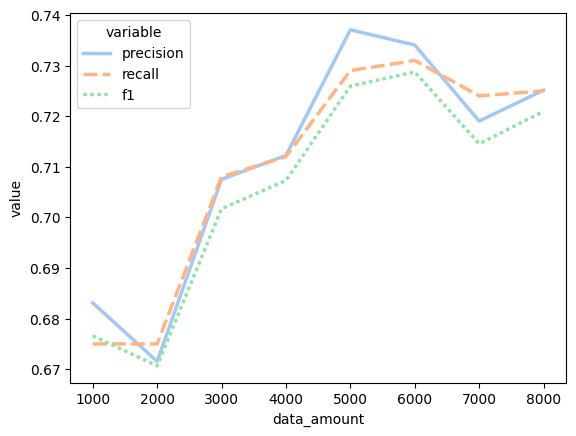

In [9]:
sns.lineplot(data=pd.melt(stats_df, ['data_amount']), x='data_amount', y='value', style="variable", hue='variable', palette="pastel", linewidth=2.5)

In [10]:
best_model

{'RandomForestGini': 5,
 'RandomForestEntr': 3,
 'ExtraTreesGini': 1,
 'ExtraTreesEntr': 3,
 'LightGBMXT': 5,
 'LightGBM': 1,
 'WeightedEnsemble_L2': 6}

([<matplotlib.patches.Wedge at 0x297d1b3d410>,
 [Text(0.872688684769691, 0.6696375582917576, 'RandomForestGini'),
  Text(-0.14357877740594208, 1.0905893519921306, 'RandomForestEntr'),
  Text(-0.6696375480783808, 0.8726886926066904, 'ExtraTreesGini'),
  Text(-1.0162674759093278, 0.42095179938905625, 'ExtraTreesEntr'),
  Text(-0.8726887004436892, -0.6696375378650044, 'LightGBMXT'),
  Text(-0.14357886675074347, -1.0905893402296634, 'LightGBM'),
  Text(0.7778174228929379, -0.7778174957174651, 'WeightedEnsemble_L2')],
 [Text(0.47601200987437686, 0.3652568499773223, '21%'),
  Text(-0.0783156967668775, 0.5948669192684347, '12%'),
  Text(-0.3652568444063895, 0.47601201414910377, '4%'),
  Text(-0.5543277141323605, 0.22961007239403064, '12%'),
  Text(-0.4760120184238304, -0.36525683883545684, '21%'),
  Text(-0.07831574550040553, -0.5948669128525436, '4%'),
  Text(0.42426404885069335, -0.4242640885731627, '25%')])

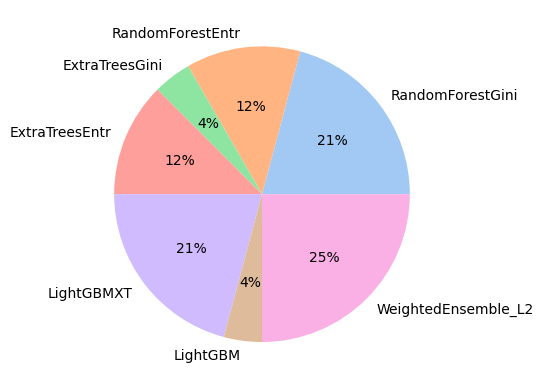

In [11]:
colors = sns.color_palette('pastel')[0:20]
plt.pie(list(best_model.values()), labels=list(best_model), colors = colors, autopct='%.0f%%')

In [12]:
best_features

{'Feature 0': 8,
 'Feature 20': 4,
 'Feature 1': 2,
 'Feature 7': 3,
 'Feature 6': 2,
 'Feature 3': 1,
 'Feature 4': 1,
 'Feature 16': 2,
 'Feature 8': 1}

([<matplotlib.patches.Wedge at 0x297d1b29bd0>,
 [Text(0.5499999702695115, 0.9526279613277875, 'Feature 0'),
  Text(-0.9526279870751434, 0.5499999256737774, 'Feature 20'),
  Text(-1.062518380041041, -0.28470105738293683, 'Feature 1'),
  Text(-0.6696374765847432, -0.8726887474656803, 'Feature 7'),
  Text(1.2873679044788556e-07, -1.0999999999999925, 'Feature 6'),
  Text(0.42095190643260955, -1.0162674315704265, 'Feature 3'),
  Text(0.6696376910656436, -0.8726885828886921, 'Feature 4'),
  Text(0.952628025696173, -0.5499998587801742, 'Feature 16'),
  Text(1.0905893704759926, -0.1435786370069675, 'Feature 8')],
 [Text(0.2999999837833699, 0.5196152516333385, '33%'),
  Text(-0.5196152656773508, 0.299999959458424, '17%'),
  Text(-0.5795554800223859, -0.15529148584523825, '8%'),
  Text(-0.36525680540985983, -0.47601204407218917, '12%'),
  Text(7.022006751702848e-08, -0.5999999999999959, '8%'),
  Text(0.22961013078142337, -0.5543276899475054, '4%'),
  Text(0.3652569223994419, -0.4760119543029229,

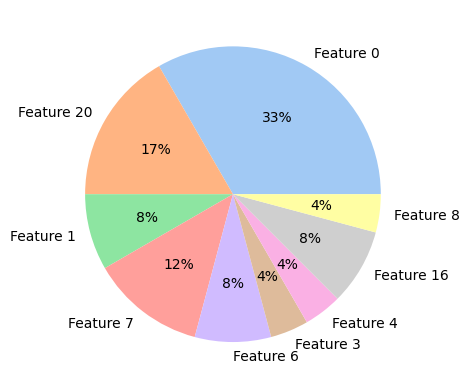

In [13]:
plt.pie(list(best_features.values()), labels=list(best_features), colors = colors, autopct='%.0f%%')

In [14]:
feature_importance

,importance,stddev,p_value,n,p99_high,p99_low
Feature 0,0.1120,0.004472,3.044013e-07,5,0.121208,0.102792
Feature 20,0.0418,0.011606,6.454138e-04,5,0.065697,0.017903
Feature 8,0.0204,0.004722,3.212635e-04,5,0.030123,0.010677
Feature 14,0.0170,0.003000,1.116990e-04,5,0.023177,0.010823
Feature 1,0.0168,0.005762,1.428894e-03,5,0.028664,0.004936
Feature 6,0.0160,0.005657,1.599101e-03,5,0.027648,0.004352
Feature 11,0.0142,0.006140,3.322931e-03,5,0.026842,0.001558
Feature 12,0.0132,0.002490,1.449907e-04,5,0.018327,0.008073
Feature 3,0.0126,0.002302,1.279861e-04,5,0.017340,0.007860
Feature 18,0.0116,0.007127,1.098967e-02,5,0.026275,-0.003075
